# 🎯 Block 1 — NumPy, Matrices & Vector Operations
## Building a Small Internal Course Recommender

> **The big idea:** many AI systems start from one simple move —
> *represent real-world objects as vectors, compare them with math, and turn the scores into decisions.*

In this notebook you build a training recommender for a company. Each **employee** and each
**training** becomes a numerical **vector** over the same skill dimensions. You then use
**matrix multiplication** to score every employee against every training **at once**:

```python
scores = employee_matrix_normalized @ training_matrix_normalized.T
```

That single line is the heart of the whole exercise.

**How this notebook works**
- Each step implements one idea, then runs a tiny `assert` **test** to check it.
- Most steps end with a **visualization** (interactive HTML, heatmaps, distributions, radar).
- It runs top-to-bottom on **Google Colab** with no setup. Just `Runtime → Run all`.


## 0. Setup
Standard scientific-Python stack — all preinstalled on Colab.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import HTML, display

np.set_printoptions(precision=3, suppress=True)
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

SKILL_COLORS = ["#4C72B0", "#DD8452", "#55A868", "#C44E52", "#8172B3", "#937860"]
print("NumPy", np.__version__, "· pandas", pd.__version__, "ready ✅")

NumPy 1.26.4 · pandas 2.3.1 ready ✅


In [2]:
#@title 📊 Visualization (double-click to view the code) { display-mode: "form" }
def pipeline_diagram():
    display(HTML('''
<style>
.pl{font-family:system-ui,Segoe UI,Roboto,sans-serif;background:linear-gradient(135deg,#f6f8ff,#fbf5ff);
    border-radius:18px;padding:22px 18px;margin:8px 0;border:1px solid #ecebff}
.pl-h{font-size:20px;font-weight:800;color:#3b2d6b;margin:0 0 4px}
.pl-s{color:#7a6fab;font-size:13px;margin:0 0 18px}
.pl-row{display:flex;align-items:flex-start;flex-wrap:wrap;gap:0}
.pl-step{flex:1 1 110px;min-width:110px;text-align:center;padding:0 4px}
.pl-ic{width:54px;height:54px;border-radius:50%;margin:0 auto 8px;display:flex;align-items:center;
       justify-content:center;font-size:24px;color:#fff;box-shadow:0 6px 14px rgba(102,126,234,.35)}
.pl-t{font-weight:700;font-size:13px;color:#2c2350}
.pl-d{font-size:11px;color:#8b86a6;margin-top:2px}
.pl-ar{display:flex;align-items:center;justify-content:center;font-size:22px;color:#b9a9e6;
       flex:0 0 18px;height:54px}
@media(max-width:680px){.pl-ar{transform:rotate(90deg);height:24px}}
</style>
<div class="pl">
  <div class="pl-h">🚀 What we are going to build</div>
  <div class="pl-s">A recommender turns raw business data into decisions through a chain of simple steps:</div>
  <div class="pl-row">
    <div class="pl-step"><div class="pl-ic" style="background:linear-gradient(135deg,#667eea,#7a8cf0)">🧑‍💼</div>
      <div class="pl-t">Business objects</div><div class="pl-d">employees &amp; trainings</div></div>
    <div class="pl-ar">➜</div>
    <div class="pl-step"><div class="pl-ic" style="background:linear-gradient(135deg,#6f7bf0,#8a73ec)">🔢</div>
      <div class="pl-t">Vectors</div><div class="pl-d">numeric profiles</div></div>
    <div class="pl-ar">➜</div>
    <div class="pl-step"><div class="pl-ic" style="background:linear-gradient(135deg,#8273ec,#9a6fe2)">🧮</div>
      <div class="pl-t">Matrices</div><div class="pl-d">stacked vectors</div></div>
    <div class="pl-ar">➜</div>
    <div class="pl-step"><div class="pl-ic" style="background:linear-gradient(135deg,#9a6fe2,#b06fd0)">📐</div>
      <div class="pl-t">Similarities</div><div class="pl-d">dot products</div></div>
    <div class="pl-ar">➜</div>
    <div class="pl-step"><div class="pl-ic" style="background:linear-gradient(135deg,#b06fd0,#c56fbe)">🏆</div>
      <div class="pl-t">Rankings</div><div class="pl-d">top-k</div></div>
    <div class="pl-ar">➜</div>
    <div class="pl-step"><div class="pl-ic" style="background:linear-gradient(135deg,#c56fbe,#db6fa9)">🎯</div>
      <div class="pl-t">Recommendations</div><div class="pl-d">+ business rules</div></div>
  </div>
</div>'''))

def heatmap(matrix, row_labels, col_labels, title, cmap="viridis", fmt=".2f", figscale=1.0):
    matrix = np.asarray(matrix, dtype=float)
    fig, ax = plt.subplots(figsize=(figscale * (1.0 * len(col_labels) + 2),
                                    figscale * (0.55 * len(row_labels) + 2)))
    im = ax.imshow(matrix, cmap=cmap, aspect="auto")
    ax.set_xticks(range(len(col_labels))); ax.set_xticklabels(col_labels, rotation=40, ha="right")
    ax.set_yticks(range(len(row_labels))); ax.set_yticklabels(row_labels)
    ax.grid(False)
    vmid = np.nanmin(matrix) + 0.6 * (np.nanmax(matrix) - np.nanmin(matrix))
    for i in range(matrix.shape[0]):
        for j in range(matrix.shape[1]):
            v = matrix[i, j]
            txt = "—" if not np.isfinite(v) else format(v, fmt)
            ax.text(j, i, txt, ha="center", va="center", fontsize=8,
                    color="white" if (np.isfinite(v) and v < vmid) else "black")
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    ax.set_title(title, fontweight="bold")
    plt.tight_layout(); plt.show()

pipeline_diagram()

# Part 1 — From raw data to a normalized matrix

We start with readable business data and turn it into the numerical objects NumPy works with:

**1.1** load the data into DataFrames & explore it · **1.2** look at distributions and normalize ·
**1.3** assemble the feature matrix.

## 1.1 — Load the employee & training data

Two small, **readable** datasets. We'll load them into **pandas DataFrames** (tabular data with
named columns) and explore them interactively before touching any math.

- **Employees** carry a skill *profile* (what they need / are interested in) plus a `role`.
- **Trainings** carry a skill *profile* (what they teach) plus business metadata:
  `cost`, `duration_hours`, `available_seats`, `mandatory_for_managers`.

> Note: *Cybersecurity Essentials* has **0 seats** (used later to demonstrate hard masks), and
> *Project Leadership* is **mandatory for managers** (used later to demonstrate a bonus).

In [3]:
employees = [
    {"name": "Alice",  "role": "manager",    "leadership": 0.8, "data_analysis": 0.3, "communication": 0.7, "project_management": 0.9, "cybersecurity": 0.2, "ai_tools": 0.6},
    {"name": "Bob",    "role": "analyst",    "leadership": 0.2, "data_analysis": 0.9, "communication": 0.4, "project_management": 0.3, "cybersecurity": 0.3, "ai_tools": 0.8},
    {"name": "Claire", "role": "specialist", "leadership": 0.3, "data_analysis": 0.4, "communication": 0.9, "project_management": 0.5, "cybersecurity": 0.1, "ai_tools": 0.4},
    {"name": "David",  "role": "engineer",   "leadership": 0.2, "data_analysis": 0.5, "communication": 0.3, "project_management": 0.4, "cybersecurity": 0.9, "ai_tools": 0.7},
    {"name": "Eve",    "role": "manager",    "leadership": 0.9, "data_analysis": 0.2, "communication": 0.6, "project_management": 0.8, "cybersecurity": 0.3, "ai_tools": 0.5},
    {"name": "Frank",  "role": "engineer",   "leadership": 0.1, "data_analysis": 0.2, "communication": 0.1, "project_management": 0.1, "cybersecurity": 1.0, "ai_tools": 0.3},
    {"name": "Grace",  "role": "specialist", "leadership": 0.3, "data_analysis": 0.0, "communication": 1.0, "project_management": 0.2, "cybersecurity": 0.0, "ai_tools": 0.1},
    {"name": "Henry",  "role": "analyst",    "leadership": 0.0, "data_analysis": 1.0, "communication": 0.1, "project_management": 0.1, "cybersecurity": 0.2, "ai_tools": 1.0},
]

trainings = [
    {"title": "AI for Managers",         "leadership": 0.4, "data_analysis": 0.6, "communication": 0.3, "project_management": 0.5, "cybersecurity": 0.2, "ai_tools": 1.0, "cost": 300, "duration_hours": 6,  "available_seats": 5,  "mandatory_for_managers": False},
    {"title": "Project Leadership",      "leadership": 0.9, "data_analysis": 0.2, "communication": 0.6, "project_management": 1.0, "cybersecurity": 0.1, "ai_tools": 0.3, "cost": 500, "duration_hours": 12, "available_seats": 3,  "mandatory_for_managers": True},
    {"title": "Communication Workshop",  "leadership": 0.4, "data_analysis": 0.1, "communication": 1.0, "project_management": 0.4, "cybersecurity": 0.0, "ai_tools": 0.2, "cost": 150, "duration_hours": 4,  "available_seats": 10, "mandatory_for_managers": False},
    {"title": "Data Analysis Bootcamp",  "leadership": 0.1, "data_analysis": 1.0, "communication": 0.3, "project_management": 0.3, "cybersecurity": 0.2, "ai_tools": 0.7, "cost": 600, "duration_hours": 20, "available_seats": 4,  "mandatory_for_managers": False},
    {"title": "Cybersecurity Essentials","leadership": 0.1, "data_analysis": 0.3, "communication": 0.2, "project_management": 0.2, "cybersecurity": 1.0, "ai_tools": 0.4, "cost": 400, "duration_hours": 8,  "available_seats": 0,  "mandatory_for_managers": False},
    {"title": "Intro to AI Tools",       "leadership": 0.2, "data_analysis": 0.5, "communication": 0.3, "project_management": 0.3, "cybersecurity": 0.3, "ai_tools": 0.9, "cost": 200, "duration_hours": 5,  "available_seats": 8,  "mandatory_for_managers": False},
    {"title": "Cybersecurity Masterclass",   "leadership": 0.0, "data_analysis": 0.2, "communication": 0.0, "project_management": 0.1, "cybersecurity": 1.0, "ai_tools": 0.2, "cost": 450, "duration_hours": 10, "available_seats": 6,  "mandatory_for_managers": False},
    {"title": "Public Speaking Intensive",   "leadership": 0.3, "data_analysis": 0.0, "communication": 1.0, "project_management": 0.2, "cybersecurity": 0.0, "ai_tools": 0.0, "cost": 180, "duration_hours": 3,  "available_seats": 12, "mandatory_for_managers": False},
    {"title": "Deep Learning Specialization","leadership": 0.0, "data_analysis": 1.0, "communication": 0.1, "project_management": 0.2, "cybersecurity": 0.3, "ai_tools": 1.0, "cost": 800, "duration_hours": 30, "available_seats": 4,  "mandatory_for_managers": False},
]

employees_df = pd.DataFrame(employees).set_index("name")
trainings_df = pd.DataFrame(trainings).set_index("title")

employee_names = list(employees_df.index)
training_titles = list(trainings_df.index)
n_employees, n_trainings = len(employees_df), len(trainings_df)

print(f"{n_employees} employees and {n_trainings} trainings loaded")
print("employee columns:", list(employees_df.columns))
print("training columns:", list(trainings_df.columns))

8 employees and 9 trainings loaded
employee columns: ['role', 'leadership', 'data_analysis', 'communication', 'project_management', 'cybersecurity', 'ai_tools']
training columns: ['leadership', 'data_analysis', 'communication', 'project_management', 'cybersecurity', 'ai_tools', 'cost', 'duration_hours', 'available_seats', 'mandatory_for_managers']


## What is a vector?

Before we build the full recommender, let's understand vectors — they're the core base of behind almost every AI system.

Think of a **vector** as a GPS coordinate for skills:
- **Alice** lives at `(leadership=0.8, data_analysis=0.3)`
- **Bob** lives at `(leadership=0.2, data_analysis=0.9)`

> 📍 **A vector is just a list of numbers.** Here, each person becomes a **point in skill space**:
> - **X‑axis** = leadership skill
> - **Y‑axis** = data analysis skill

We'll start with just **2 skills** to build intuition — then scale to all **6 skills** later.

👇 **Click the tabs below** to see each person's vector as an arrow. Watch how the arrow's **direction** tells you what they're good at!

In [4]:
#@title 🎯 2D Vector Explorer - All Employees { display-mode: "form" }

import json as _json
import numpy as np
from IPython.display import HTML, display

_VECTOR_EXPLORER = '''
<style>
#__UID__{font-family:system-ui,Segoe UI,Roboto,sans-serif;border:1px solid #e6e8ee;border-radius:16px;padding:16px;background:#fff;max-width:900px}
#__UID__ .exp-head{font-size:16px;font-weight:800;margin-bottom:10px;color:#3b2d6b}
#__UID__ .exp-tabs{display:flex;flex-wrap:wrap;gap:6px;margin-bottom:14px;max-height:120px;overflow-y:auto;padding:4px}
#__UID__ .exp-tab{cursor:pointer;border:1px solid #d7dae6;background:#f6f7fb;border-radius:999px;padding:6px 12px;font-size:13px;transition:.15s}
#__UID__ .exp-tab:hover{border-color:#764ba2}
#__UID__ .exp-tab.active{background:linear-gradient(135deg,#667eea,#764ba2);color:#fff;border-color:transparent}
#__UID__ .vector-container{display:flex;gap:20px;flex-wrap:wrap;margin-top:15px}
#__UID__ .profile-panel{flex:1;min-width:250px}
#__UID__ .viz-panel{flex:1;min-width:280px;text-align:center}
#__UID__ .exp-title{font-size:18px;font-weight:800;margin-bottom:6px;color:#2c2350}
#__UID__ .exp-title small{font-weight:400;color:#999;font-size:13px}
#__UID__ .exp-meta{margin-bottom:10px}
#__UID__ .exp-chip{display:inline-block;background:#eef0f7;border-radius:8px;padding:3px 8px;margin:2px;font-size:12px;color:#555}
#__UID__ .exp-row{display:flex;align-items:center;gap:10px;margin:5px 0}
#__UID__ .exp-k{width:150px;font-size:12px;color:#444;text-align:right}
#__UID__ .exp-track{flex:1;background:#eef0f5;border-radius:6px;height:12px;overflow:hidden}
#__UID__ .exp-fill{display:block;height:12px;border-radius:6px;transition:width .4s ease}
#__UID__ .exp-v{width:38px;font-size:12px;color:#666}
#__UID__ canvas{border:1px solid #e6e8ee;border-radius:12px;background:#fefefe;width:100%;max-width:320px;height:auto;box-shadow:0 2px 8px rgba(0,0,0,0.05)}
#__UID__ .vector-note{font-size:11px;color:#8b86a6;margin-top:8px}
#__UID__ .all-vectors-note{font-size:11px;color:#667eea;margin-top:8px;text-align:center;background:#f6f8ff;padding:6px;border-radius:8px}
</style>
<div id="__UID__">
  <div class="exp-head">__HEAD__</div>
  <div class="exp-tabs">__TABS__</div>
  <div class="vector-container">
    <div class="profile-panel">
      <div class="exp-panel"></div>
    </div>
    <div class="viz-panel">
      <canvas id="vectorCanvas___UID__" width="320" height="320" style="width:100%; max-width:320px; height:auto"></canvas>
      <div class="vector-note">📐 Arrow from (0,0) to (leadership, data_analysis)</div>
      <div class="all-vectors-note" id="allVectorsNote___UID__"></div>
    </div>
  </div>
</div>
<script>
(function(){
  const D = __DATA__;
  const COLORS = __COLORS__;
  const root = document.getElementById("__UID__");
  const panel = root.querySelector(".exp-panel");
  const tabs = root.querySelectorAll(".exp-tab");
  const canvas = document.getElementById("vectorCanvas___UID__");
  const ctx = canvas.getContext("2d");
  const allVectorsNote = document.getElementById("allVectorsNote___UID__");
  
  function drawAllVectors(highlightIndex) {
    const w = canvas.width;
    const h = canvas.height;
    const padding = 40;
    const xRange = 1.1;
    const yRange = 1.1;
    
    function scaleX(x) { return padding + (x / xRange) * (w - 2*padding); }
    function scaleY(y) { return h - padding - (y / yRange) * (h - 2*padding); }
    
    ctx.clearRect(0, 0, w, h);
    
    // Draw axes
    ctx.beginPath();
    ctx.strokeStyle = "#ccc";
    ctx.lineWidth = 1;
    ctx.moveTo(padding, h - padding);
    ctx.lineTo(w - padding, h - padding);
    ctx.moveTo(padding, h - padding);
    ctx.lineTo(padding, padding);
    ctx.stroke();
    
    // Draw ALL employees as faint arrows first
    for (let idx = 0; idx < D.length; idx++) {
      const person = D[idx];
      const isHighlighted = (idx === highlightIndex);
      
      const x1 = padding;
      const y1 = h - padding;
      const x2 = scaleX(person.leadership);
      const y2 = scaleY(person.analysis);
      
      ctx.beginPath();
      ctx.moveTo(x1, y1);
      ctx.lineTo(x2, y2);
      
      if (isHighlighted) {
        ctx.strokeStyle = person.color;
        ctx.lineWidth = 3;
        ctx.setLineDash([]);
      } else {
        ctx.strokeStyle = "#d0d0d0";
        ctx.lineWidth = 1.5;
        ctx.setLineDash([5, 5]);
      }
      ctx.stroke();
      
      // Draw end point
      ctx.beginPath();
      ctx.arc(x2, y2, isHighlighted ? 5 : 3, 0, 2*Math.PI);
      ctx.fillStyle = isHighlighted ? person.color : "#bbb";
      ctx.fill();
      
      if (isHighlighted) {
        ctx.fillStyle = "white";
        ctx.beginPath();
        ctx.arc(x2, y2, 2, 0, 2*Math.PI);
        ctx.fill();
        
        // Arrowhead for highlighted
        const angle = Math.atan2(y2 - y1, x2 - x1);
        const headlen = 10;
        ctx.beginPath();
        ctx.moveTo(x2, y2);
        ctx.lineTo(x2 - headlen * Math.cos(angle - Math.PI/6), y2 - headlen * Math.sin(angle - Math.PI/6));
        ctx.lineTo(x2 - headlen * Math.cos(angle + Math.PI/6), y2 - headlen * Math.sin(angle + Math.PI/6));
        ctx.fillStyle = person.color;
        ctx.fill();
        
        // Label
        ctx.fillStyle = person.color;
        ctx.font = "bold 11px system-ui";
        ctx.fillText(person.name, x2 + 5, y2 - 5);
      }
    }
    
    ctx.setLineDash([]);
    
    // Labels
    ctx.fillStyle = "#8b86a6";
    ctx.font = "10px system-ui";
    ctx.fillText("leadership →", w - 45, h - padding + 12);
    ctx.save();
    ctx.translate(18, h/2);
    ctx.rotate(-Math.PI/2);
    ctx.fillText("data analysis →", -25, 0);
    ctx.restore();
    
    // Update note
    allVectorsNote.innerHTML = "👥 " + D.length + " employees shown as faint arrows | Highlighted: " + D[highlightIndex].name;
  }
  
  function render(i){
    const r = D[i];
    let bars = "";
    Object.keys(r.skills).forEach(function(k, idx){
      const v = r.skills[k];
      bars += '<div class="exp-row"><span class="exp-k">'+k+'</span>'+
              '<span class="exp-track"><span class="exp-fill" style="width:'+(v*100)+'%;background:'+COLORS[idx%COLORS.length]+'"></span></span>'+
              '<span class="exp-v">'+Number(v).toFixed(2)+'</span></div>';
    });
    let meta = "";
    Object.keys(r.meta).forEach(function(k){ meta += '<span class="exp-chip">'+k+': '+r.meta[k]+'</span>'; });
    panel.innerHTML = '<div class="exp-title">'+r.name+(r.subtitle?' <small>'+r.subtitle+'</small>':'')+'</div>'+
                      (meta?'<div class="exp-meta">'+meta+'</div>':'')+bars;
    
    drawAllVectors(i);
    
    tabs.forEach(function(t,j){ t.classList.toggle("active", j===i); });
  }
  
  tabs.forEach(function(t,i){ t.addEventListener("click", function(){ render(i); }); });
  render(0);
})();
</script>
'''

# Color palette for different employees
employee_colors = [
    "#4C72B0",  # Alice - blue
    "#DD8452",  # Bob - orange
    "#55A868",  # Claire - green
    "#C44E52",  # David - red
    "#8172B3",  # Eve - purple
    "#937860",  # Frank - brown
    "#DA8B9E",  # Grace - pink
    "#6B8B9E"   # Henry - steel blue
]

# Prepare data for ALL employees
vector_records = []
for idx, (name, row) in enumerate(employees_df.iterrows()):
    vector_records.append({
        "name": name,
        "subtitle": row["role"],
        "leadership": float(row["leadership"]),
        "analysis": float(row["data_analysis"]),
        "color": employee_colors[idx % len(employee_colors)],
        "skills": {
            "leadership": float(row["leadership"]),
            "data_analysis": float(row["data_analysis"])
        },
        "meta": {"role": row["role"]}
    })

# Generate unique ID
uid = "vec_all_" + str(abs(hash("all_employees_vector")) % 10**8)
tabs_html = "".join(f'<div class="exp-tab">{r["name"]}</div>' for r in vector_records)

html_output = (_VECTOR_EXPLORER
    .replace("__UID__", uid)
    .replace("__HEAD__", "🎯 2D Vector Explorer — All Employees (leadership vs data_analysis)")
    .replace("__TABS__", tabs_html)
    .replace("__DATA__", _json.dumps(vector_records))
    .replace("__COLORS__", _json.dumps(employee_colors))
)

display(HTML(html_output))


**Interactive explorer** 🕹️ — click a name/title to inspect a single profile.

This is a small self-contained HTML+JS widget (works on Colab, no extra packages).

In [5]:
#@title 📊 Visualization (double-click to view the code) { display-mode: "form" }
import json as _json

_EXPLORER = '''
<style>
#__UID__{font-family:system-ui,Segoe UI,Roboto,sans-serif;border:1px solid #e6e8ee;border-radius:16px;padding:16px;background:#fff;max-width:700px}
#__UID__ .exp-head{font-size:16px;font-weight:800;margin-bottom:10px}
#__UID__ .exp-tabs{display:flex;flex-wrap:wrap;gap:6px;margin-bottom:14px}
#__UID__ .exp-tab{cursor:pointer;border:1px solid #d7dae6;background:#f6f7fb;border-radius:999px;padding:6px 12px;font-size:13px;transition:.15s}
#__UID__ .exp-tab:hover{border-color:#764ba2}
#__UID__ .exp-tab.active{background:linear-gradient(135deg,#667eea,#764ba2);color:#fff;border-color:transparent}
#__UID__ .exp-title{font-size:18px;font-weight:800;margin-bottom:6px}
#__UID__ .exp-title small{font-weight:400;color:#999;font-size:13px}
#__UID__ .exp-meta{margin-bottom:10px}
#__UID__ .exp-chip{display:inline-block;background:#eef0f7;border-radius:8px;padding:3px 8px;margin:2px;font-size:12px;color:#555}
#__UID__ .exp-row{display:flex;align-items:center;gap:10px;margin:5px 0}
#__UID__ .exp-k{width:150px;font-size:12px;color:#444;text-align:right}
#__UID__ .exp-track{flex:1;background:#eef0f5;border-radius:6px;height:12px;overflow:hidden}
#__UID__ .exp-fill{display:block;height:12px;border-radius:6px;transition:width .4s ease}
#__UID__ .exp-v{width:38px;font-size:12px;color:#666}
</style>
<div id="__UID__">
  <div class="exp-head">__HEAD__</div>
  <div class="exp-tabs">__TABS__</div>
  <div class="exp-panel"></div>
</div>
<script>
(function(){
  const D = __DATA__, COLORS = __COLORS__;
  const root = document.getElementById("__UID__");
  const panel = root.querySelector(".exp-panel");
  const tabs = root.querySelectorAll(".exp-tab");
  function render(i){
    const r = D[i]; let bars = "";
    Object.keys(r.skills).forEach(function(k, idx){
      const v = r.skills[k];
      bars += '<div class="exp-row"><span class="exp-k">'+k+'</span>'+
              '<span class="exp-track"><span class="exp-fill" style="width:'+(v*100)+'%;background:'+COLORS[idx%COLORS.length]+'"></span></span>'+
              '<span class="exp-v">'+Number(v).toFixed(2)+'</span></div>';
    });
    let meta = "";
    Object.keys(r.meta).forEach(function(k){ meta += '<span class="exp-chip">'+k+': '+r.meta[k]+'</span>'; });
    panel.innerHTML = '<div class="exp-title">'+r.name+(r.subtitle?' <small>'+r.subtitle+'</small>':'')+'</div>'+
                      (meta?'<div class="exp-meta">'+meta+'</div>':'')+bars;
    tabs.forEach(function(t,j){ t.classList.toggle("active", j===i); });
  }
  tabs.forEach(function(t,i){ t.addEventListener("click", function(){ render(i); }); });
  render(0);
})();
</script>
'''

def profile_explorer(records, heading, colors=SKILL_COLORS):
    uid = "exp_" + str(abs(hash(heading)) % 10**8)
    tabs = "".join('<div class="exp-tab">' + r["name"] + '</div>' for r in records)
    html = (_EXPLORER.replace("__UID__", uid).replace("__HEAD__", heading)
            .replace("__TABS__", tabs)
            .replace("__DATA__", _json.dumps(records))
            .replace("__COLORS__", _json.dumps(colors)))
    display(HTML(html))

emp_records = [{"name": e["name"], "subtitle": e["role"],
                "skills": {k: v for k, v in e.items() if k not in ("name", "role")}, "meta": {}}
               for e in employees]
profile_explorer(emp_records, "👤 Employee profile explorer — click a name")

In [6]:
#@title 📊 Visualization (double-click to view the code) { display-mode: "form" }
_meta_keys = ("title", "cost", "duration_hours", "available_seats", "mandatory_for_managers")
trn_records = [{"name": t["title"], "subtitle": "training",
                "skills": {k: v for k, v in t.items() if k not in _meta_keys},
                "meta": {"cost": "$" + str(t["cost"]),
                         "duration": str(t["duration_hours"]) + "h",
                         "seats": t["available_seats"],
                         "mandatory(mgr)": t["mandatory_for_managers"]}}
               for t in trainings]
profile_explorer(trn_records, "🎓 Training catalog explorer — click a title")

## 1.2 — Distributions & normalization

Everything so far lived in **pandas DataFrames** — great for *labeled, mixed-type* data (names,
roles, and numbers all together). But the math behind a recommender works on plain **numbers**, so
our first move is to convert the skill columns into a **NumPy array**.

A **NumPy array** (`ndarray`) is just a **grid of numbers, all of the same type, with a fixed shape**:
a 1-D array is a *vector*, a 2-D array is a *matrix*. It is the data structure that essentially every
numerical and machine-learning library expects. The diagram below shows *what* the conversion does
and *why* it is worth it.

In [7]:
#@title 📊 Visualization (double-click to view the code) { display-mode: "form" }
display(HTML('''
<style>
.na{font-family:system-ui,Segoe UI,Roboto,sans-serif;color:#2c2350;max-width:760px}
.na h4{margin:4px 0 10px}
.na-flow{display:flex;align-items:center;gap:14px;flex-wrap:wrap;justify-content:center;margin:6px 0 18px}
.na-card{background:#fff;border:1px solid #e6e8ee;border-radius:14px;padding:12px 14px;box-shadow:0 3px 10px rgba(0,0,0,.05)}
.na-cap{font-size:11px;color:#8b86a6;text-align:center;margin-top:8px;line-height:1.4}
.na-tbl{border-collapse:collapse;font-size:12px}
.na-tbl th,.na-tbl td{border:1px solid #e6e8ee;padding:5px 8px;text-align:center}
.na-tbl th{background:#f6f7fb;color:#555}
.na-dim{color:#bbb;background:#fbfbfd}
.na-hl{background:#eef0ff;font-weight:600;color:#3b2d6b}
.na-arrow{font-size:12px;color:#764ba2;text-align:center;font-weight:600;line-height:1.5}
.na-arrow .big{font-size:26px;display:block;color:#b9a9e6}
.na-grid{display:inline-grid;gap:4px}
.na-cell{width:44px;height:30px;border-radius:6px;background:linear-gradient(135deg,#eef0ff,#f7eefc);
         border:1px solid #e2def5;display:flex;align-items:center;justify-content:center;font-size:12px;color:#3b2d6b}
.na-axt{font-size:10px;color:#8b86a6;text-align:center;margin-bottom:3px}
.na-axl{font-size:10px;color:#8b86a6;writing-mode:vertical-rl;transform:rotate(180deg);align-self:center}
.na-why{display:flex;flex-wrap:wrap;gap:10px}
.na-w{flex:1 1 170px;background:#fff;border:1px solid #e6e8ee;border-radius:12px;padding:11px 13px}
.na-w b{display:block;font-size:13px;margin-bottom:3px}
.na-w span{font-size:12px;color:#7a7596;line-height:1.45}
.na code{background:#f1eefb;padding:1px 5px;border-radius:5px;font-size:12px}
</style>
<div class="na">
  <h4>📦 What is a NumPy array — and why convert our table into one?</h4>
  <div class="na-flow">
    <div class="na-card">
      <table class="na-tbl">
        <tr><th>name</th><th>role</th><th>leadership</th><th>data_analysis</th><th>…</th></tr>
        <tr><td class="na-dim">Alice</td><td class="na-dim">manager</td><td class="na-hl">0.8</td><td class="na-hl">0.3</td><td class="na-hl">…</td></tr>
        <tr><td class="na-dim">Bob</td><td class="na-dim">analyst</td><td class="na-hl">0.2</td><td class="na-hl">0.9</td><td class="na-hl">…</td></tr>
        <tr><td class="na-dim">Claire</td><td class="na-dim">specialist</td><td class="na-hl">0.3</td><td class="na-hl">0.4</td><td class="na-hl">…</td></tr>
      </table>
      <div class="na-cap">DataFrame · labels + mixed types<br>(text <i>and</i> numbers)</div>
    </div>
    <div class="na-arrow"><span class="big">➜</span>keep skill columns<br><code>.to_numpy()</code></div>
    <div class="na-card">
      <div style="display:flex;gap:8px">
        <div class="na-axl">axis 0 ↓ · rows = employees</div>
        <div>
          <div class="na-axt">axis 1 → · columns = skills</div>
          <div class="na-grid" style="grid-template-columns:repeat(3,44px)">
            <div class="na-cell">0.8</div><div class="na-cell">0.3</div><div class="na-cell">0.7</div>
            <div class="na-cell">0.2</div><div class="na-cell">0.9</div><div class="na-cell">0.4</div>
            <div class="na-cell">0.3</div><div class="na-cell">0.4</div><div class="na-cell">0.9</div>
          </div>
        </div>
      </div>
      <div class="na-cap">ndarray · one pure block of numbers<br>shape = (5, 6) · dtype = float64</div>
    </div>
  </div>
  <div class="na-why">
    <div class="na-w"><b>⚡ Fast</b><span>Numbers live in one compact block and operations run in compiled C, not slow Python loops.</span></div>
    <div class="na-w"><b>🧮 Whole-dataset ops</b><span>One expression acts on the entire array at once — e.g. normalize every row together.</span></div>
    <div class="na-w"><b>📡 Broadcasting</b><span>Combine arrays of different shapes automatically (a per-training penalty over all employees).</span></div>
    <div class="na-w"><b>➗ Linear algebra</b><span>Dot products, matrix multiply <code>@</code> and norms are built in — the engine of the recommender.</span></div>
  </div>
</div>'''))

name,role,leadership,data_analysis,…
Alice,manager,0.8,0.3,…
Bob,analyst,0.2,0.9,…
Claire,specialist,0.3,0.4,…


### Build the array: pick your columns, then mask

Our DataFrames hold more than skills. Look at the columns printed above: `employees_df` also has a
text `role`, and `trainings_df` has `cost`, `duration_hours`, `available_seats` and
`mandatory_for_managers`. For the math we want a **purely numeric array of just the skill columns**.
So there are two things to do — and *you* do them:

**1. Decide which columns are features.** That is the `skill_features` list. You choose which
columns to keep (and in which order).

**2. Keep only those columns, using a boolean mask.** A *boolean mask* is an array of `True`/`False`
the same length as the axis you index; indexing with it keeps the positions that are `True`. It is
one of the most useful NumPy tools — we will use it again for business rules later.

```python
values = np.array([10, 20, 30, 40])
mask   = np.array([True, False, True, False])
values[mask]            # -> array([10, 30])     keeps positions where mask is True
```

For a **2-D** array, `array[:, mask]` applies the mask to the **columns** (the `:` keeps all rows).
We build that column mask with `np.isin(columns, skill_features)`, which is `True` wherever a column
name appears in your list:

```python
columns = np.array(["role", "leadership", "data_analysis", ...])
np.isin(columns, skill_features)     # -> array([False, True, True, ...])
```

> 💡 A mask keeps columns in their **original order**, so list `skill_features` in the order the
> columns appear in the DataFrame — it will not reorder them for you.

In [8]:
# 👉 TASK 1 — choose the columns to keep as numeric features (the skill dimensions).
skill_features = ["leadership", "data_analysis", "communication",
                  "project_management", "cybersecurity", "ai_tools"]
n_features = len(skill_features)

# 👉 TASK 2 — keep ONLY those columns, as a NumPy array, using a boolean column mask.
employee_cols = np.array(employees_df.columns)        # ['role', 'leadership', ...]
training_cols = np.array(trainings_df.columns)        # [..., 'cost', 'duration_hours', ...]

employee_keep = np.isin(employee_cols, skill_features)   # True on the skill columns
training_keep = np.isin(training_cols, skill_features)

# array[:, mask] keeps every row but only the columns where the mask is True
employee_matrix = employees_df.to_numpy()[:, employee_keep].astype(float)
training_matrix = trainings_df.to_numpy()[:, training_keep].astype(float)

# stack employees + trainings so we can study all rows together
all_raw = np.vstack([employee_matrix, training_matrix])
all_labels = employee_names + training_titles

# sanity check: masking should keep exactly the skill columns, in DataFrame order
assert np.array_equal(employee_matrix, employees_df[skill_features].to_numpy(dtype=float)), \
    "Hint: your mask should select exactly the skill columns — check the column order."

print("kept columns :", employee_cols[employee_keep].tolist())
print("employee_matrix:", employee_matrix.shape, "· training_matrix:", training_matrix.shape)
print("stacked array  :", all_raw.shape, "(rows = items, columns = skills)")

kept columns : ['leadership', 'data_analysis', 'communication', 'project_management', 'cybersecurity', 'ai_tools']
employee_matrix: (8, 6) · training_matrix: (9, 6)
stacked array  : (17, 6) (rows = items, columns = skills)


### First, look at the raw vectors

Before changing anything, let's inspect what we have. In the chart below, the left panel shows the
spread of values per skill — but the **right panel is the important one**. It shows each row's
**length** (its L2 norm, $\lVert x \rVert = \sqrt{\sum_i x_i^2}$). Notice the lengths are all
**different**: some employees and trainings are simply "bigger" vectors than others.

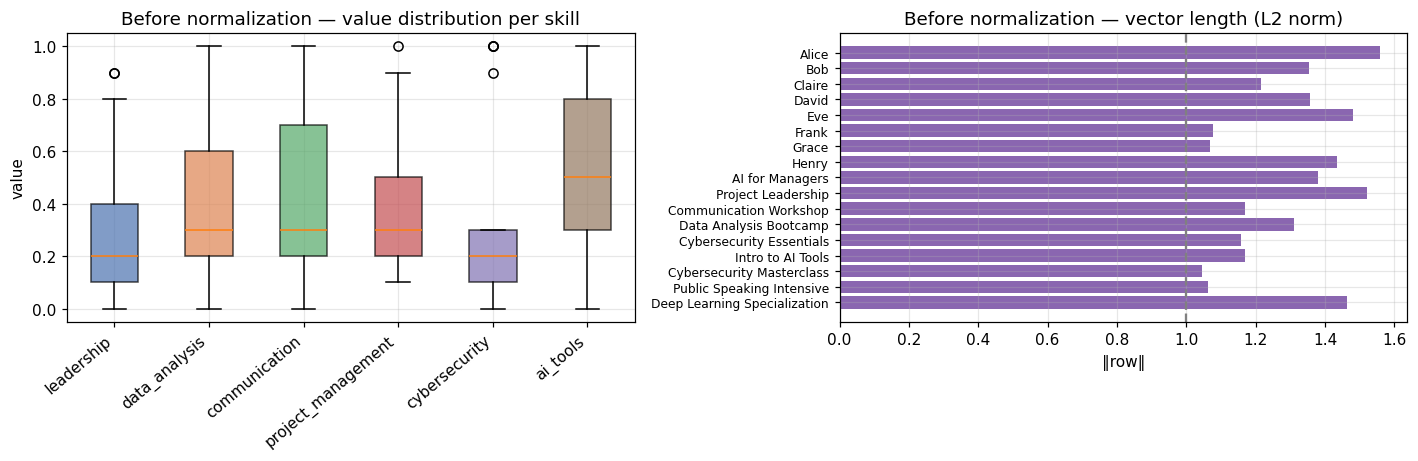

In [9]:
#@title 📊 Visualization (double-click to view the code) { display-mode: "form" }
def plot_dist_and_norms(matrix, row_labels, title):
    fig, (axb, axn) = plt.subplots(1, 2, figsize=(13, 4.3))
    bp = axb.boxplot([matrix[:, j] for j in range(matrix.shape[1])], patch_artist=True)
    for patch, c in zip(bp["boxes"], SKILL_COLORS):
        patch.set_facecolor(c); patch.set_alpha(0.7)
    axb.set_xticks(range(1, matrix.shape[1] + 1))
    axb.set_xticklabels(skill_features, rotation=40, ha="right")
    axb.set_title(f"{title} — value distribution per skill"); axb.set_ylabel("value")

    norms = np.linalg.norm(matrix, axis=1)
    axn.barh(range(len(row_labels)), norms, color="#764ba2", alpha=0.85)
    axn.set_yticks(range(len(row_labels))); axn.set_yticklabels(row_labels, fontsize=8)
    axn.invert_yaxis(); axn.axvline(1.0, ls="--", color="gray")
    axn.set_title(f"{title} — vector length (L2 norm)"); axn.set_xlabel("‖row‖")
    plt.tight_layout(); plt.show()

plot_dist_and_norms(all_raw, all_labels, "Before normalization")

### Why is that a problem?

When we compare two profiles later, a *longer* vector tends to score higher against **everything** —
not because it is a better match, but simply because its numbers are larger. Magnitude drowns out
**direction**, yet direction is what carries the meaning: *what a profile is about* (lots of
leadership? mostly data analysis?), regardless of how big the raw numbers are.

The 2-D picture below makes this concrete. **A** and **B** point the **same way** — they describe the
same kind of profile — but **B** is twice as long, so a raw comparison would treat them as different.

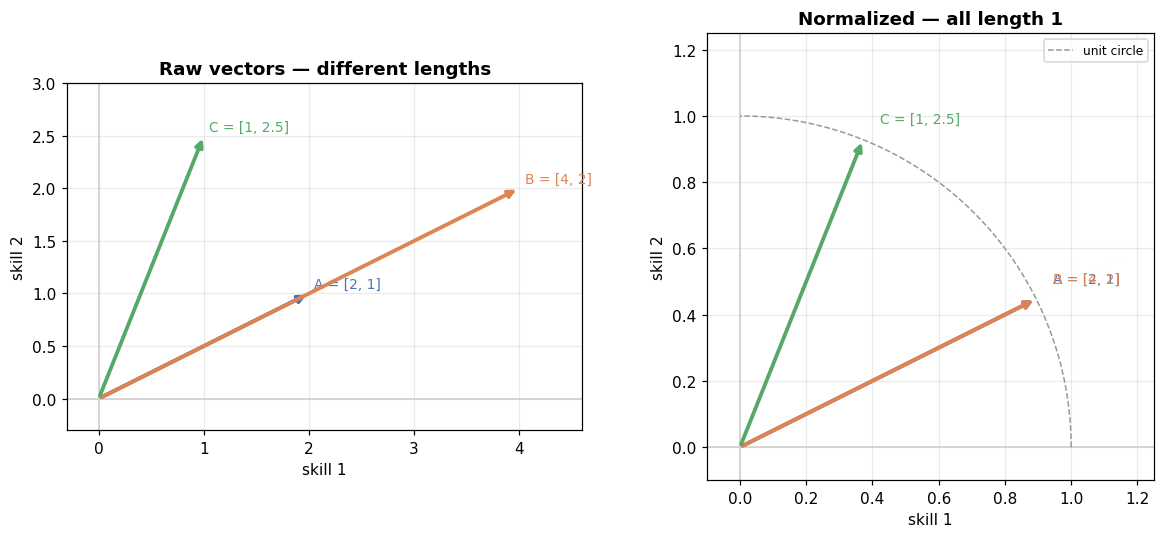

A normalized: [0.894 0.447]
B normalized: [0.894 0.447]  <- identical to A: same direction, size removed


In [10]:
#@title 📊 Visualization (double-click to view the code) { display-mode: "form" }
# illustrative 2-D example: same idea, just two skills so we can draw it
demo = np.array([[2.0, 1.0], [4.0, 2.0], [1.0, 2.5]])
demo_labels = ["A = [2, 1]", "B = [4, 2]", "C = [1, 2.5]"]
demo_colors = ["#4C72B0", "#DD8452", "#55A868"]
demo_norm = demo / np.linalg.norm(demo, axis=1, keepdims=True)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 5))
for ax, data, title in [(ax1, demo, "Raw vectors — different lengths"),
                        (ax2, demo_norm, "Normalized — all length 1")]:
    for v, lab, c in zip(data, demo_labels, demo_colors):
        ax.annotate("", xy=v, xytext=(0, 0), arrowprops=dict(arrowstyle="-|>", color=c, lw=2.5))
        ax.text(v[0] + 0.05, v[1] + 0.05, lab, color=c, fontsize=9)
    ax.axhline(0, color="#ccc", lw=1); ax.axvline(0, color="#ccc", lw=1)
    ax.set_aspect("equal"); ax.set_xlabel("skill 1"); ax.set_ylabel("skill 2")
    ax.set_title(title, fontweight="bold"); ax.grid(alpha=0.25)

theta = np.linspace(0, np.pi / 2, 100)
ax2.plot(np.cos(theta), np.sin(theta), "--", color="#999", lw=1, label="unit circle")
ax2.legend(loc="upper right", fontsize=8)
ax1.set_xlim(-0.3, 4.6); ax1.set_ylim(-0.3, 3.0)
ax2.set_xlim(-0.1, 1.25); ax2.set_ylim(-0.1, 1.25)
plt.tight_layout(); plt.show()

print("A normalized:", demo_norm[0])
print("B normalized:", demo_norm[1], " <- identical to A: same direction, size removed")

### What normalization is — and why it fixes this

We rescale every vector to **length 1** by dividing it by its own length:

$$\hat{x} = \frac{x}{\lVert x \rVert}, \qquad \lVert x \rVert = \sqrt{\textstyle\sum_i x_i^2}$$

Now every profile lands on the **unit circle** (right panel above): they are all the same size, so a
comparison can depend *only on direction*. Notice that **A** and **B** collapse onto the **exact same
point** — once size is removed, they are revealed to be the same profile. That is exactly the
property we want before measuring similarity.

### 👉 Your task: implement `normalize_rows`

Now turn that idea into code: scale **each row** of a 2-D array to unit (L2) length.

> 💡 Compute the norm with `np.linalg.norm(X, axis=1, keepdims=True)`. Using `axis=1` takes the
> norm of each **row**; `keepdims=True` keeps the result shaped `(n_rows, 1)` so the division
> **broadcasts** cleanly across columns.

In [11]:
def normalize_rows(X):
    '''Scale each row of 2-D array X to unit (L2) length.'''
    norms = np.linalg.norm(X, axis=1, keepdims=True)
    return X / norms

**Apply it, then test** ✅

In [12]:
employee_matrix_normalized = normalize_rows(employee_matrix)
training_matrix_normalized = normalize_rows(training_matrix)
all_norm = np.vstack([employee_matrix_normalized, training_matrix_normalized])

row_norms = np.linalg.norm(all_norm, axis=1)
assert np.allclose(row_norms, 1.0), \
    "Hint: did you use axis=1 and keepdims=True? Every row should end up with length 1."
print("1.2 passed ✅  all", len(row_norms), "rows now have length 1.0")

1.2 passed ✅  all 17 rows now have length 1.0


**After normalization** — every vector now sits on the unit sphere (all norms = 1).

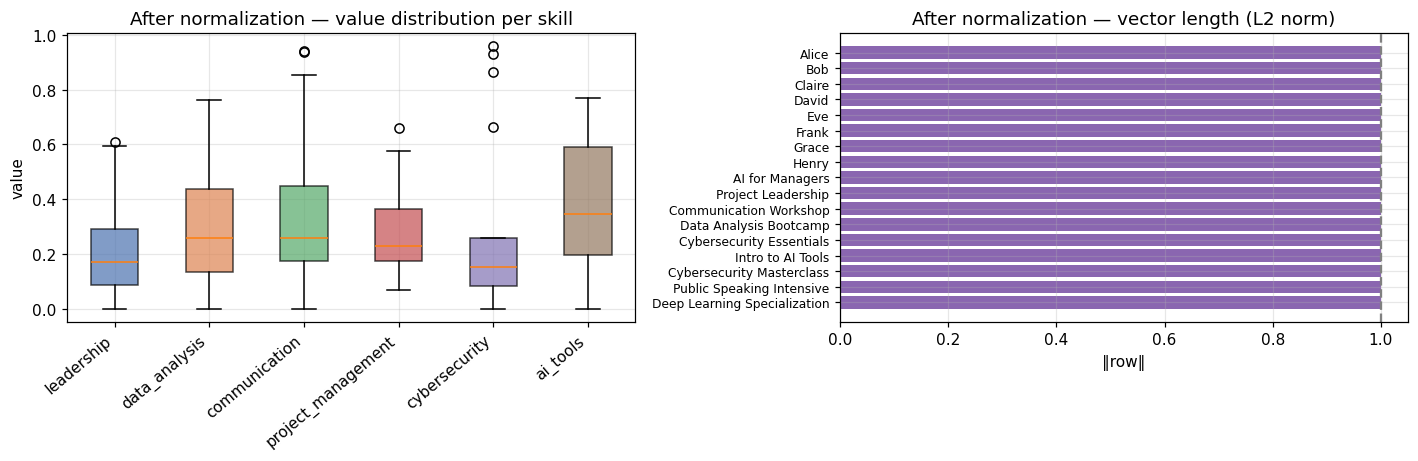

In [13]:
#@title 📊 Visualization (double-click to view the code) { display-mode: "form" }
plot_dist_and_norms(all_norm, all_labels, "After normalization")

## 1.3 — Build & inspect the feature matrix

A **matrix** is just rows stacked together, and `np.vstack` does exactly that. We already used it
back in **1.2** to combine our two matrices into `all_raw`. Let's confirm that relationship using
the variables we already have, then inspect the matrix the way you would in real work.

In [14]:
# np.vstack stacks arrays on top of each other — in 1.2 we built `all_raw` this way:
rebuilt = np.vstack([employee_matrix, training_matrix])
assert np.array_equal(rebuilt, all_raw), \
    "Hint: all_raw is the two matrices stacked — employees on top, then trainings."

print("employee_matrix.shape =", employee_matrix.shape, " → (n_employees, n_features)")
print("ndim =", employee_matrix.ndim, "· dtype =", employee_matrix.dtype, "· size =", employee_matrix.size)
print()
print("How to print a matrix (rows = employees, columns = skills):")
print(employee_matrix)

employee_matrix.shape = (8, 6)  → (n_employees, n_features)
ndim = 2 · dtype = float64 · size = 48

How to print a matrix (rows = employees, columns = skills):
[[0.8 0.3 0.7 0.9 0.2 0.6]
 [0.2 0.9 0.4 0.3 0.3 0.8]
 [0.3 0.4 0.9 0.5 0.1 0.4]
 [0.2 0.5 0.3 0.4 0.9 0.7]
 [0.9 0.2 0.6 0.8 0.3 0.5]
 [0.1 0.2 0.1 0.1 1.  0.3]
 [0.3 0.  1.  0.2 0.  0.1]
 [0.  1.  0.1 0.1 0.2 1. ]]


**Test** ✅

In [15]:
assert employee_matrix.shape == (n_employees, n_features), "Hint: rows = items, columns = features."
assert training_matrix.shape == (n_trainings, n_features), "Hint: did the stack/extract keep all rows?"
print("1.3 passed ✅")

1.3 passed ✅


**Formatted view** — the three matrices as clean, annotated heatmaps. Compare the top two:
normalization keeps each row's *pattern* but rescales it so every row has the same overall size.

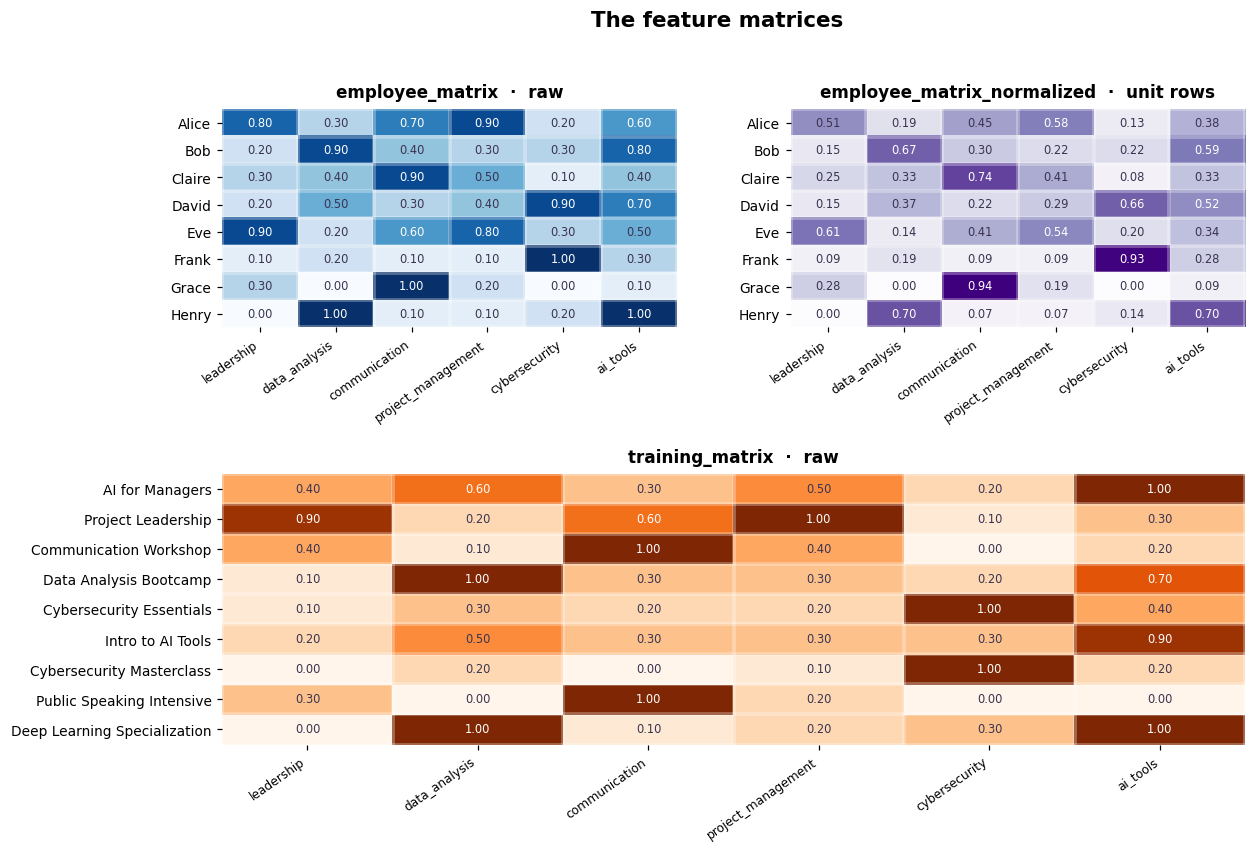

In [16]:
#@title 📊 Visualization (double-click to view the code) { display-mode: "form" }
def tile(ax, M, rows, cols, title, cmap):
    M = np.asarray(M, dtype=float)
    ax.imshow(M, cmap=cmap, aspect="auto", vmin=0, vmax=M.max())
    ax.set_xticks(range(len(cols))); ax.set_xticklabels(cols, rotation=35, ha="right", fontsize=8)
    ax.set_yticks(range(len(rows))); ax.set_yticklabels(rows, fontsize=9)
    thr = 0.55 * M.max()
    for i in range(M.shape[0]):
        for j in range(M.shape[1]):
            ax.text(j, i, f"{M[i, j]:.2f}", ha="center", va="center", fontsize=7.5,
                    color="white" if M[i, j] > thr else "#3a3350")
    # thin white gaps between cells for a clean "tiled" look
    ax.set_xticks(np.arange(-0.5, len(cols), 1), minor=True)
    ax.set_yticks(np.arange(-0.5, len(rows), 1), minor=True)
    ax.grid(which="major", visible=False)
    ax.grid(which="minor", color="white", lw=2.5)
    ax.tick_params(which="minor", length=0)
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.set_title(title, fontweight="bold", fontsize=11, pad=8)

fig = plt.figure(figsize=(12, 7.5))
gs = fig.add_gridspec(2, 2, height_ratios=[5, 6.2], hspace=0.6, wspace=0.25)
tile(fig.add_subplot(gs[0, 0]), employee_matrix, employee_names, skill_features,
     "employee_matrix  ·  raw", "Blues")
tile(fig.add_subplot(gs[0, 1]), employee_matrix_normalized, employee_names, skill_features,
     "employee_matrix_normalized  ·  unit rows", "Purples")
tile(fig.add_subplot(gs[1, :]), training_matrix, training_titles, skill_features,
     "training_matrix  ·  raw", "Oranges")
fig.suptitle("The feature matrices", fontweight="bold", fontsize=14, y=1.0)
plt.show()

# Part 2 — Comparing & ranking

## Step 4 — The dot product (one employee, one training)

The **dot product** measures how aligned two vectors are:

$$a \cdot b = \sum_i a_i b_i$$

In general the dot product mixes *direction* and *size*. But remember we **normalized** every row back
in Part 1, so our profiles are already **unit vectors** (length 1). For unit vectors the dot product
is exactly the **cosine similarity** — a pure measure of *direction*: a high score means the two
profiles point the same way, with no influence from magnitude (which we deliberately removed).

We implement it by hand first, *then* check it matches NumPy's `@` operator.

In [17]:
def dot_product(a, b):
    '''Element-wise multiply, then sum.'''
    return np.sum(a * b)

alice = employee_matrix_normalized[0]
ai_course = training_matrix_normalized[0]
print("manual dot product   :", dot_product(alice, ai_course))
print("NumPy  alice @ course:", alice @ ai_course)

manual dot product   : 0.8377078165833911
NumPy  alice @ course: 0.8377078165833912


**Test** ✅

In [18]:
assert np.isclose(dot_product(alice, ai_course), alice @ ai_course), \
    "Hint: a * b multiplies element-wise; np.sum then adds them up."
print("Step 4 passed ✅  our dot_product matches the @ operator")

Step 4 passed ✅  our dot_product matches the @ operator


**Visualization — why this is a good score.** Below we compare **Alice** (blue) against three
trainings: one that matches her well, one that overlaps only partly, and one that barely matches. For
each skill we draw Alice's bar and the course's bar. Where **both bars are full**, that skill adds a
lot to the dot product; where one is short, it adds little. So the course whose bars line up with
Alice's earns the highest score — exactly the behaviour we want.

In [19]:
#@title 📊 Visualization (double-click to view the code) { display-mode: "form" }
_MF_STYLE = '''
<style>
.mf-wrap{display:flex;flex-wrap:wrap;gap:14px;font-family:system-ui,Segoe UI,Roboto,sans-serif}
.mf-card{flex:1 1 250px;background:#fff;border:1px solid #e6e8ee;border-radius:14px;padding:14px;box-shadow:0 3px 10px rgba(0,0,0,.05)}
.mf-h{font-weight:800;font-size:14px;color:#2c2350;display:flex;flex-direction:column;gap:6px;margin-bottom:4px}
.mf-badge{align-self:flex-start;color:#fff;font-size:11px;font-weight:700;border-radius:999px;padding:3px 10px}
.mf-leg{font-size:11px;margin-bottom:10px}
.mf-leg span{margin-right:10px;font-weight:600}
.mf-row{display:flex;align-items:center;gap:8px;margin:5px 0}
.mf-k{width:118px;font-size:11px;color:#555;text-align:right}
.mf-bars{flex:1;display:flex;flex-direction:column;gap:2px}
.mf-bar{background:#eef0f5;border-radius:4px;height:7px;overflow:hidden}
.mf-fill{display:block;height:7px;border-radius:4px}
</style>'''

def match_explainer(employee_index, course_indices):
    emp_name = employee_names[employee_index]
    emp_raw = employee_matrix[employee_index]
    emp_unit = employee_matrix_normalized[employee_index]

    def verdict(s):
        if s >= 0.90: return ("Strong match", "#1f9d55", "🟢")
        if s >= 0.70: return ("Partial match", "#c98a00", "🟡")
        return ("Weak match", "#c0392b", "🔴")

    cards = ""
    for ci in course_indices:
        course, crs_raw = training_titles[ci], training_matrix[ci]
        s = float(dot_product(emp_unit, training_matrix_normalized[ci]))   # = cosine similarity
        label, color, dot = verdict(s)
        rows = ""
        for f, av, cv in zip(skill_features, emp_raw, crs_raw):
            rows += (f'<div class="mf-row"><span class="mf-k">{f}</span><div class="mf-bars">'
                     f'<span class="mf-bar"><i class="mf-fill" style="width:{av*100:.0f}%;background:#4C72B0"></i></span>'
                     f'<span class="mf-bar"><i class="mf-fill" style="width:{cv*100:.0f}%;background:{color}"></i></span>'
                     f'</div></div>')
        cards += (f'<div class="mf-card"><div class="mf-h">{course}'
                  f'<span class="mf-badge" style="background:{color}">{dot} {label} · score {s:.2f}</span></div>'
                  f'<div class="mf-leg"><span style="color:#4C72B0">▮ {emp_name}</span>'
                  f'<span style="color:{color}">▮ {course}</span></div>{rows}</div>')
    display(HTML(_MF_STYLE + '<div class="mf-wrap">' + cards + "</div>"))

# Alice (index 0) vs a strong (Project Leadership), a partial (Communication Workshop),
# and a weak (Cybersecurity Essentials) training
match_explainer(0, [1, 2, 4])

## Step 5 — All scores at once with matrix multiplication ⭐

This is the **core moment**. Instead of looping over every (employee, training) pair, one matrix
multiply computes **all** the similarities simultaneously:

```python
scores = employee_matrix_normalized @ training_matrix_normalized.T
```

**What matrix multiplication actually computes.** Every entry of a product is *one row of the left
matrix times one column of the right matrix* — multiply them term by term, then add up:

$$(AB)_{ij} = \sum_{k} A_{ik}\,B_{kj}$$

Here the left matrix is the employees (rows = employees, columns = features) and the right matrix is
the **transposed** trainings (rows = features, columns = trainings). So each output cell is exactly the
dot product — the cosine similarity — of one employee with one training:

$$\text{scores}_{ij} \;=\; \sum_{f} E_{if}\,T_{jf} \;=\; (\text{employee } i)\cdot(\text{training } j)$$

> 💡 That `.T` is what makes the shapes line up: `(employees, features) @ (features, trainings)`.
> The shared **features** dimension sits in the middle and cancels, leaving `(employees, trainings)` —
> the full score grid. The diagram below shows one cell being computed; matrix multiplication does the
> same for **every** cell at once.

In [20]:
#@title 📊 Visualization (double-click to view the code) { display-mode: "form" }
display(HTML('''
<style>
.mm{font-family:system-ui,Segoe UI,Roboto,sans-serif;background:linear-gradient(135deg,#f7f8ff,#fdf6ff);
    border:1px solid #ecebff;border-radius:16px;padding:18px;margin:8px 0}
.mm-flow{display:flex;align-items:center;justify-content:center;gap:12px;flex-wrap:wrap}
.mm-b{text-align:center}
.mm-name{font-size:12px;font-weight:800;color:#3b2d6b}
.mm-sub{font-size:10px;color:#8b86a6;margin-bottom:6px}
.mm-grid{display:inline-grid;gap:3px;padding:6px;background:#fff;border:1px solid #e6e8ee;border-radius:10px}
.mm-c{width:22px;height:22px;border-radius:5px;background:#eef0f5}
.mm-rh{background:#bcd0f5}
.mm-ch{background:#f6d3b0}
.mm-xh{background:linear-gradient(135deg,#9a6fe2,#c56fbe)}
.mm-op{font-size:24px;color:#b9a9e6;font-weight:800}
.mm-eq{margin-top:14px;text-align:center;font-size:13px;color:#2c2350;line-height:1.7}
.mm-eq .bl{color:#3a63c0;font-weight:700}.mm-eq .or{color:#c07a39;font-weight:700}.mm-eq .pu{color:#8a4fd0;font-weight:700}
.mm-cap{margin-top:8px;text-align:center;font-size:11px;color:#8b86a6}
</style>
<div class="mm">
  <div class="mm-flow">
    <div class="mm-b">
      <div class="mm-name">employee_matrix (E)</div><div class="mm-sub">employees × features</div>
      <div class="mm-grid" style="grid-template-columns:repeat(4,22px)">
        <div class="mm-c"></div><div class="mm-c"></div><div class="mm-c"></div><div class="mm-c"></div>
        <div class="mm-c mm-rh"></div><div class="mm-c mm-rh"></div><div class="mm-c mm-rh"></div><div class="mm-c mm-rh"></div>
        <div class="mm-c"></div><div class="mm-c"></div><div class="mm-c"></div><div class="mm-c"></div>
      </div>
    </div>
    <div class="mm-op">✕</div>
    <div class="mm-b">
      <div class="mm-name">training_matrixᵀ (Tᵀ)</div><div class="mm-sub">features × trainings</div>
      <div class="mm-grid" style="grid-template-columns:repeat(3,22px)">
        <div class="mm-c"></div><div class="mm-c mm-ch"></div><div class="mm-c"></div>
        <div class="mm-c"></div><div class="mm-c mm-ch"></div><div class="mm-c"></div>
        <div class="mm-c"></div><div class="mm-c mm-ch"></div><div class="mm-c"></div>
        <div class="mm-c"></div><div class="mm-c mm-ch"></div><div class="mm-c"></div>
      </div>
    </div>
    <div class="mm-op">=</div>
    <div class="mm-b">
      <div class="mm-name">scores</div><div class="mm-sub">employees × trainings</div>
      <div class="mm-grid" style="grid-template-columns:repeat(3,22px)">
        <div class="mm-c"></div><div class="mm-c"></div><div class="mm-c"></div>
        <div class="mm-c"></div><div class="mm-c mm-xh"></div><div class="mm-c"></div>
        <div class="mm-c"></div><div class="mm-c"></div><div class="mm-c"></div>
      </div>
    </div>
  </div>
  <div class="mm-eq"><span class="pu">scores[i, j]</span> = ( <span class="bl">row i</span> of E ) · ( <span class="or">column j</span> of Tᵀ ) = &Sigma;<sub>f</sub> E[i,f]·T[j,f]</div>
  <div class="mm-cap">One <b style="color:#3a63c0">blue row</b> × one <b style="color:#c07a39">orange column</b> → one <b style="color:#8a4fd0">purple cell</b>. Matrix multiplication fills in every (employee, training) cell this way, all at once.</div>
</div>'''))

In [21]:
# 🎯 TASK — work out the shapes before you write a single line of code.
#    Fill in the blanks. Run this cell — if you got them right, the assert passes.

# employee_matrix_normalized.shape  = (8, 6)   # rows = employees, cols = features
# training_matrix_normalized.shape  = (8, 6)   # rows = trainings, cols = features
# training_matrix_normalized.T shape= (6, 8)   # .T swaps rows <-> cols
# scores.shape should be            = (8, 8)   # rows = employees, cols = trainings

# Once the shapes make sense, implement the function:

def compute_score_matrix(employee_matrix, training_matrix):
    return employee_matrix @ training_matrix.T

scores = compute_score_matrix(employee_matrix_normalized, training_matrix_normalized)
print("scores.shape =", scores.shape, " (employees x trainings)")


scores.shape = (8, 9)  (employees x trainings)


**Test** ✅

In [22]:
assert scores.shape == (n_employees, n_trainings), "Hint: did you transpose the training matrix?"
assert np.isclose(scores[0, 0],
                  dot_product(employee_matrix_normalized[0], training_matrix_normalized[0])), \
    "Hint: scores[0,0] must equal the manual dot product of employee 0 and training 0."
print("Step 5 passed ✅  one @ replaced", n_employees * n_trainings, "separate dot products")

Step 5 passed ✅  one @ replaced 72 separate dot products


### Discussion:

#### Q: After we normalize rows, what is the length of each employee vector?

**A:** Exactly **1.0**. `normalize_rows` divides each row by its own L2 norm, so every employee (and training) vector is rescaled onto the **unit sphere** — its length becomes 1. Only the *direction* (the mix of skills) survives; the overall magnitude is discarded. That is what we want: two profiles should count as *similar* when they point the same way, regardless of how strong their raw scores are.

#### Q: Why do we use training_matrix.T in the matrix multiplication?

**A:** Matrix multiplication `A @ B` requires the **inner dimensions to match** — the number of columns of `A` must equal the number of rows of `B`.

`employee_matrix_normalized` is `(8, 6)` (employees × features) and `training_matrix_normalized` is also `(8, 6)` (trainings × features), so `(8,6) @ (8,6)` is **illegal**. Transposing gives `training_matrix_normalized.T` of shape `(6, 8)` (features × trainings), and now `(8,6) @ (6,8) = (8,8)`.

Crucially, each entry `scores[i, j]` becomes the **dot product of employee *i*'s feature vector with training *j*'s feature vector** (their cosine similarity, since both are unit vectors). The `.T` is what lines the features up against each other.

**Visualization** — the full similarity matrix: **🔴 red = weak**, **🟢 green = strong**. Scan
across one employee's row to spot their best-fitting trainings at a glance.

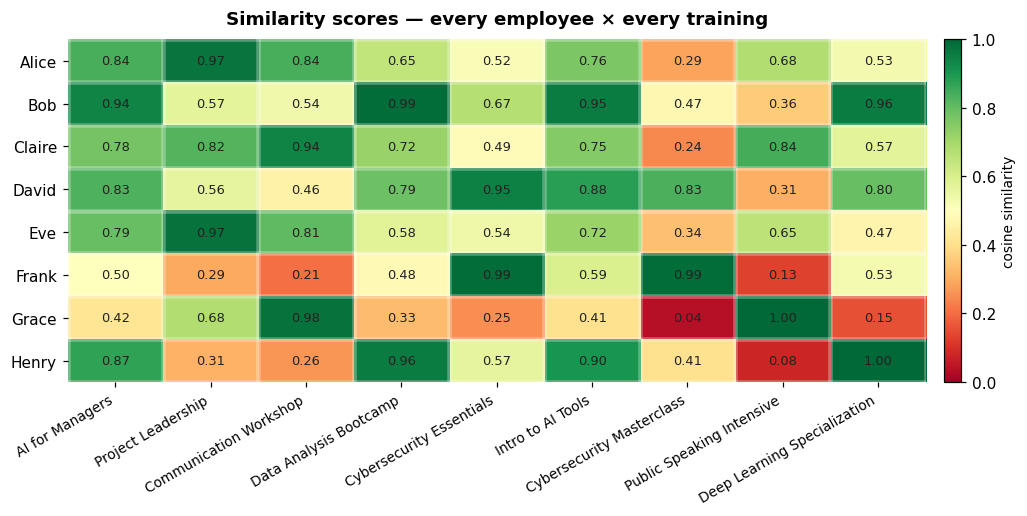

In [23]:
#@title 📊 Visualization (double-click to view the code) { display-mode: "form" }
fig, ax = plt.subplots(figsize=(9.5, 4.8))
im = ax.imshow(scores, cmap="RdYlGn", aspect="auto", vmin=0, vmax=1)
ax.set_xticks(range(n_trainings)); ax.set_xticklabels(training_titles, rotation=30, ha="right", fontsize=9)
ax.set_yticks(range(n_employees)); ax.set_yticklabels(employee_names, fontsize=10)
for i in range(n_employees):
    for j in range(n_trainings):
        ax.text(j, i, f"{scores[i, j]:.2f}", ha="center", va="center", fontsize=8.5, color="#222")
# thin white gaps + no spines for a clean, tiled look
ax.set_xticks(np.arange(-0.5, n_trainings, 1), minor=True)
ax.set_yticks(np.arange(-0.5, n_employees, 1), minor=True)
ax.grid(which="major", visible=False)
ax.grid(which="minor", color="white", lw=3)
ax.tick_params(which="minor", length=0)
for spine in ax.spines.values():
    spine.set_visible(False)
cbar = fig.colorbar(im, ax=ax, fraction=0.025, pad=0.02)
cbar.set_label("cosine similarity", fontsize=9)
ax.set_title("Similarity scores — every employee × every training", fontweight="bold", fontsize=12, pad=10)
plt.tight_layout(); plt.show()

## Step 6 — Top-k recommendations

The score matrix tells us *how well* every employee matches every training — but people want a short
**list of suggestions**, not a grid of numbers. So for each employee we take their row of scores,
**sort the trainings from best to worst, and keep the top `k`**.

We do this with `np.argsort`, which returns the **positions (indices)** that would sort an array —
not the sorted values themselves. That's handy because the index *is* the training number we want to
look up. One catch: `argsort` orders from **smallest to largest**, so we reverse it with `[::-1]` to
put the **highest** scores first, then slice the first `k`:

```python
np.argsort(row)             # training indices, worst → best
np.argsort(row)[::-1]       # reversed: best → worst
np.argsort(row)[::-1][:k]   # just the top-k training indices
```

In [24]:
def get_top_k_trainings(scores, employee_index, k):
    return np.argsort(scores[employee_index])[::-1][:k]

for i, name in enumerate(employee_names):
    top = get_top_k_trainings(scores, i, 3)
    print(f"{name:7s}:", ", ".join(training_titles[j] for j in top))

Alice  : Project Leadership, Communication Workshop, AI for Managers
Bob    : Data Analysis Bootcamp, Deep Learning Specialization, Intro to AI Tools
Claire : Communication Workshop, Public Speaking Intensive, Project Leadership
David  : Cybersecurity Essentials, Intro to AI Tools, Cybersecurity Masterclass
Eve    : Project Leadership, Communication Workshop, AI for Managers
Frank  : Cybersecurity Masterclass, Cybersecurity Essentials, Intro to AI Tools
Grace  : Public Speaking Intensive, Communication Workshop, Project Leadership
Henry  : Deep Learning Specialization, Data Analysis Bootcamp, Intro to AI Tools


**Test** ✅

In [25]:
top_k = get_top_k_trainings(scores, employee_index=0, k=3)
assert len(top_k) == 3, "Hint: slice [:k]."
assert scores[0, top_k[0]] >= scores[0, top_k[1]] >= scores[0, top_k[2]], \
    "Hint: argsort is ascending — reverse it with [::-1]."
print("Step 6 passed ✅")

Step 6 passed ✅


**HTML visualization** — styled recommendation cards 🎴

In [26]:
#@title 📊 Visualization (double-click to view the code) { display-mode: "form" }
def recommendation_cards(score_matrix, k=3, title="Top recommendations"):
    cards = ""
    for i, name in enumerate(employee_names):
        order = [j for j in np.argsort(score_matrix[i])[::-1] if np.isfinite(score_matrix[i, j])][:k]
        items = ""
        medals = ["🥇", "🥈", "🥉"] + ["▫️"] * k
        for rank, j in enumerate(order):
            s = score_matrix[i, j]
            pct = max(0, min(100, int(100 * s / max(score_matrix[i].max(), 1e-9))))
            items += f'''
              <div style="margin:6px 0">
                <div style="display:flex;justify-content:space-between;font-size:13px">
                  <span>{medals[rank]} {training_titles[j]}</span><span style="opacity:.7">{s:.3f}</span>
                </div>
                <div style="background:#eef0f5;border-radius:6px;height:8px;margin-top:3px">
                  <div style="width:{pct}%;height:8px;border-radius:6px;
                       background:linear-gradient(90deg,#667eea,#764ba2)"></div>
                </div>
              </div>'''
        cards += f'''
          <div style="flex:1 1 240px;background:white;border:1px solid #e6e8ee;border-radius:14px;
               padding:14px 16px;box-shadow:0 3px 10px rgba(0,0,0,.05)">
            <div style="font-weight:700;font-size:15px">{name}
              <span style="font-weight:400;color:#888;font-size:12px">· {employees[i]['role']}</span></div>
            {items}
          </div>'''
    display(HTML(f'''
      <div style="font-family:system-ui,Segoe UI,Roboto,sans-serif">
        <h3 style="margin:6px 0">{title}</h3>
        <div style="display:flex;flex-wrap:wrap;gap:14px">{cards}</div>
      </div>'''))

recommendation_cards(scores, k=3, title="Pure-similarity recommendations")

## Step 7 — Making it realistic: extending the recommender

So far our recommender is **purely mathematical** — it ranks trainings only by how well their content
matches an employee's profile. That's a solid core, but a recommendation people will actually act on
has to respect the real world too: trainings **cost money**, **take time**, have a limited number of
**seats**, and some are **mandatory** for certain roles. The best *mathematical* match isn't always
the best *practical* one.

So let's **extend the exercise**: we keep the similarity scores as the foundation and *adjust* them
with business rules. This is where the recommender stops being a toy and starts behaving like a real
system — and it only takes two NumPy ideas:

1. **Soft penalties (broadcasting).** Expensive or long trainings should be slightly less attractive,
   but not ruled out. We subtract a small normalized **cost** and **duration** penalty from every
   score — a gentle nudge, not a veto.
2. **Hard rules (masks).** Some rules are absolute. A **sold-out** training (0 seats) is simply
   impossible, so we force its score to `-∞`; and a training that is **mandatory for managers** gets a
   strong bonus so it rises to the top for them.

> 💡 `normalized_cost` has shape `(n_trainings,)` while `scores` has shape `(n_employees, n_trainings)`.
> Thanks to **broadcasting**, NumPy applies each per-training penalty across *all* employees
> automatically — no loop needed.

### A different kind of normalization: min-max

To combine **cost** and **duration** into a single penalty we hit a problem: they live on completely
different scales — cost is in *hundreds of dollars*, duration in *hours*. If we subtracted them
directly, cost would dominate simply because its numbers are bigger. So first we put them on a
**common 0–1 scale**, and for that we use a *different* normalization from Part 1.

- **L2 (vector) normalization** — *Part 1* — divides each **row** by its length so the whole profile
  becomes a unit-length *direction*. It is about comparing the **shape** of vectors:
  `x / np.linalg.norm(x)`.
- **Min-max normalization** — *here* — rescales a **single quantity** so its smallest value maps to
  **0** and its largest to **1**:

$$x_{\text{scaled}} = \frac{x - \min(x)}{\max(x) - \min(x)}$$

So min-max stretches/squeezes one column into the range $[0, 1]$, whereas L2 shrinks a whole vector
onto the unit sphere — same word, different goal. After min-max, the cheapest training has cost
penalty `0` and the priciest has `1` (likewise for duration), so the two penalties are finally
comparable and we can add them up.

In [27]:
# pull the business columns out as NumPy feature arrays
cost_feature      = trainings_df["cost"].to_numpy(dtype=float)
duration_feature  = trainings_df["duration_hours"].to_numpy(dtype=float)
seats_feature     = trainings_df["available_seats"].to_numpy(dtype=float)
mandatory_feature = trainings_df["mandatory_for_managers"].to_numpy(dtype=bool)
manager_feature   = (employees_df["role"] == "manager").to_numpy()

# 👉 TASK — implement min-max normalization, then apply it to cost and duration
def min_max(x):
    return (x - x.min()) / (x.max() - x.min())

normalized_cost = min_max(cost_feature)
normalized_duration = min_max(duration_feature)

print("cost      ", cost_feature,     "->", normalized_cost.round(2))
print("duration  ", duration_feature, "->", normalized_duration.round(2))

cost       [300. 500. 150. 600. 400. 200. 450. 180. 800.] -> [0.23 0.54 0.   0.69 0.38 0.08 0.46 0.05 1.  ]
duration   [ 6. 12.  4. 20.  8.  5. 10.  3. 30.] -> [0.11 0.33 0.04 0.63 0.19 0.07 0.26 0.   1.  ]


### Applying the rules to the scores

Now we fold those values into the similarity matrix. There are **three** adjustments:

**1. Soft penalties** (broadcasting) — make expensive / long trainings a little less attractive:

$$\text{final}_{ij} = \text{scores}_{ij} \;-\; 0.10\,\widehat{\text{cost}}_j \;-\; 0.05\,\widehat{\text{dur}}_j$$

Each penalty has shape `(n_trainings,)` and **broadcasts** down every employee row.

**2. Hard mask** (sold-out) — a training with **0 seats** is impossible, so blank out its whole column:

$$\text{final}_{:,\,j} = -\infty \quad\text{wherever } \text{seats}_j = 0$$

**3. Mandatory bonus** — give a boost where an employee **is a manager** *and* the training **is
mandatory for managers**:

$$\text{final}_{ij} \mathrel{+}= 0.5 \quad\text{wherever } \text{manager}_i \text{ and } \text{mandatory}_j$$

> 💡 **Hints** — the NumPy operations to reach for:
> - **Penalties:** subtract `0.10 * normalized_cost` and `0.05 * normalized_duration` from `scores`
>   (the `(n_trainings,)` arrays broadcast over all employees automatically).
> - **Sold-out:** select the columns where `seats_feature == 0` with `final_scores[:, mask]`, and
>   assign `-np.inf`.
> - **Bonus:** combine `manager_feature[:, None]` (a column) with `mandatory_feature[None, :]` (a row)
>   using `&` to build a 2-D mask, then `+= 0.5` on those positions.

In [28]:
# 👉 TASK — turn the three rules above into NumPy operations

# 1) soft penalties: a per-training penalty broadcasts across all employees
final_scores = scores - 0.10 * normalized_cost - 0.05 * normalized_duration

# 2) hard mask: a sold-out training (0 seats) is impossible -> -infinity for everyone
final_scores[:, seats_feature == 0] = -np.inf

# 3) bonus: managers get a boost on trainings mandatory for managers
bonus_mask = manager_feature[:, None] & mandatory_feature[None, :]
final_scores[bonus_mask] += 0.5

print("Trainings forced to -inf (0 seats):",
      [training_titles[j] for j in np.where(seats_feature == 0)[0]])
print("Manager bonus applied at cells:", list(zip(*np.where(bonus_mask))))

Trainings forced to -inf (0 seats): ['Cybersecurity Essentials']
Manager bonus applied at cells: [(0, 1), (4, 1)]


**Test** ✅

In [29]:
assert final_scores.shape == scores.shape, "Hint: penalties should broadcast, not change the shape."
assert np.all(np.isneginf(final_scores[:, seats_feature == 0])), "Hint: zero-seat columns must be -inf for everyone."
assert final_scores[0, 1] > scores[0, 1], "Hint: Alice is a manager; Project Leadership is mandatory -> +0.5 bonus."
print("Step 7 passed ✅")

Step 7 passed ✅


**Visualization** — raw similarity vs final scores, side by side on the same **🔴→🟢** scale.
Watch the **sold-out** training turn grey (impossible) and the **mandatory** training light up bright
green for the managers.

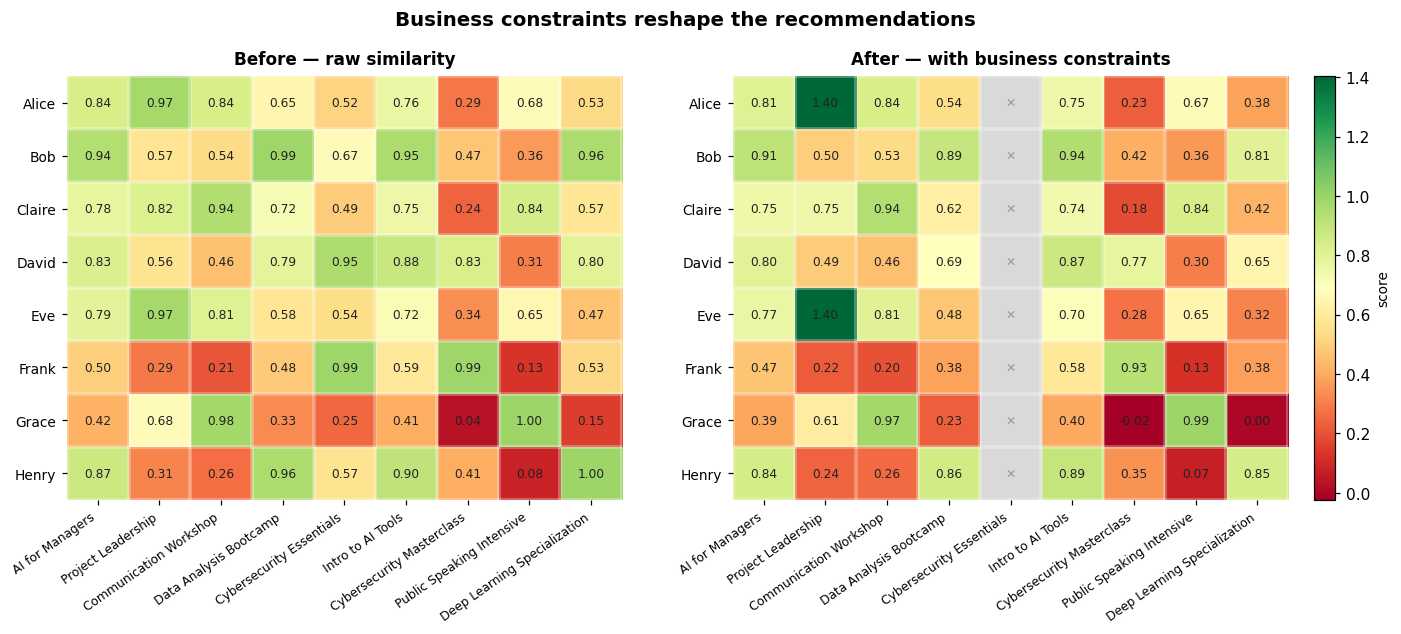

In [30]:
#@title 📊 Visualization (double-click to view the code) { display-mode: "form" }
final_for_plot = np.where(np.isfinite(final_scores), final_scores, np.nan)

cmap = plt.get_cmap("RdYlGn").copy()
cmap.set_bad("#d9d9d9")   # sold-out cells (score -inf -> NaN) shown grey

# shared colour scale so the two panels are directly comparable
vmin = min(0.0, float(np.nanmin(final_for_plot)))
vmax = max(1.0, float(np.nanmax(final_for_plot)))

def score_panel(ax, M, title):
    M = np.asarray(M, dtype=float)
    im = ax.imshow(M, cmap=cmap, aspect="auto", vmin=vmin, vmax=vmax)
    ax.set_xticks(range(n_trainings)); ax.set_xticklabels(training_titles, rotation=35, ha="right", fontsize=8)
    ax.set_yticks(range(n_employees)); ax.set_yticklabels(employee_names, fontsize=9)
    for i in range(M.shape[0]):
        for j in range(M.shape[1]):
            v = M[i, j]
            ax.text(j, i, "✕" if np.isnan(v) else f"{v:.2f}", ha="center", va="center",
                    fontsize=8, color="#999" if np.isnan(v) else "#222")
    ax.set_xticks(np.arange(-0.5, n_trainings, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, n_employees, 1), minor=True)
    ax.grid(which="major", visible=False)
    ax.grid(which="minor", color="white", lw=2.5)
    ax.tick_params(which="minor", length=0)
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.set_title(title, fontweight="bold", fontsize=11, pad=8)
    return im

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
score_panel(axes[0], scores, "Before — raw similarity")
im = score_panel(axes[1], final_for_plot, "After — with business constraints")
cbar = fig.colorbar(im, ax=axes, fraction=0.025, pad=0.02)
cbar.set_label("score", fontsize=9)
fig.suptitle("Business constraints reshape the recommendations", fontweight="bold", fontsize=13, y=1.0)
plt.show()

### Reading the results

Numbers are nice, but what do they *mean*? Here is the story the final scores tell — these notes are
generated from the data, so they stay correct if you change the inputs.

In [31]:
#@title 📊 Visualization (double-click to view the code) { display-mode: "form" }
def rank_of(M, i, j):
    return int(np.where(np.argsort(M[i])[::-1] == j)[0][0]) + 1   # 1-based rank of training j for employee i

soldout = np.where(seats_feature == 0)[0]
mandatory_idx = np.where(mandatory_feature)[0]
managers = np.where(manager_feature)[0]
insights = []

for j in soldout:
    fans = [employee_names[i] for i in range(n_employees) if int(np.argmax(scores[i])) == j]
    txt = f"🎟️ <b>{training_titles[j]}</b> is sold out (0 seats) → removed for <b>everyone</b>, however well it fits."
    if fans:
        txt += f" It was actually the top content match for <b>{', '.join(fans)}</b>, who now fall back to their next-best option."
    insights.append(txt)

for j in mandatory_idx:
    if len(managers):
        ranks = "/".join("#" + str(rank_of(final_scores, i, j)) for i in managers)
        who = ", ".join(employee_names[i] for i in managers)
        insights.append(f"⭐ <b>{training_titles[j]}</b> is mandatory for managers → after the bonus it lands at "
                        f"rank {ranks} for {who}, regardless of pure similarity.")

pj, dj = int(np.argmax(cost_feature)), int(np.argmax(duration_feature))
insights.append(f"💰 Cost &amp; time matter: the priciest course <b>{training_titles[pj]}</b> (${int(cost_feature[pj])}) and the "
                f"longest <b>{training_titles[dj]}</b> ({int(duration_feature[dj])}h) get nudged down, even where the content is a strong match.")

changed = [employee_names[i] for i in range(n_employees)
           if int(np.argmax(scores[i])) != int(np.argmax(final_scores[i]))]
insights.append(f"🔀 In total <b>{len(changed)} of {n_employees}</b> employees end up with a different #1 recommendation "
                f"than pure similarity would give" + (f": {', '.join(changed)}." if changed else "."))

items = "".join(f'<li style="margin:8px 0;line-height:1.5">{t}</li>' for t in insights)
display(HTML(f'''
<div style="font-family:system-ui,Segoe UI,Roboto,sans-serif;background:linear-gradient(135deg,#f5f7ff,#fdf5ff);
     border:1px solid #ecebff;border-radius:16px;padding:18px 22px;margin:8px 0">
  <div style="font-size:16px;font-weight:800;color:#3b2d6b;margin-bottom:6px">🔎 How the business rules changed the recommendations</div>
  <ul style="margin:0;padding-left:20px;color:#2c2350;font-size:13px">{items}</ul>
</div>'''))

## Step 8 — Bonus: employee similarity

This last step is a **bonus**: the *same* matrix-multiply trick that matched employees to trainings
can also match employees **to each other** — just multiply the employee matrix by its own transpose.

Why would we want that? Imagine organising people into **groups**. Sometimes you want a
**homogeneous** group — people with *similar* profiles who can dive deep together — and sometimes a
**heterogeneous** one — people with *different* strengths who complement each other. Employee
similarity gives us exactly the number we need to build either kind.

```python
employee_similarity = employee_matrix_normalized @ employee_matrix_normalized.T
```

In [32]:
employee_similarity = employee_matrix_normalized @ employee_matrix_normalized.T

def find_most_similar_employee(employee_index):
    sims = employee_similarity[employee_index].copy()
    sims[employee_index] = -np.inf  # don't match yourself
    return int(np.argmax(sims))

for i, name in enumerate(employee_names):
    j = find_most_similar_employee(i)
    print(f"{name:7s} is most similar to {employee_names[j]:7s}  ({employee_similarity[i, j]:.3f})")

Alice   is most similar to Eve      (0.988)
Bob     is most similar to Henry    (0.943)
Claire  is most similar to Alice    (0.896)
David   is most similar to Frank    (0.890)
Eve     is most similar to Alice    (0.988)
Frank   is most similar to David    (0.890)
Grace   is most similar to Claire   (0.870)
Henry   is most similar to Bob      (0.943)


**Test** ✅

In [33]:
assert employee_similarity.shape == (n_employees, n_employees), "Hint: emp @ emp.T."
assert np.allclose(np.diag(employee_similarity), 1.0), "Hint: a unit vector is perfectly similar to itself."
assert np.allclose(employee_similarity, employee_similarity.T), "Hint: similarity is symmetric."
print("Step 8 passed ✅")

Step 8 passed ✅


**Visualization** — employee-to-employee similarity (**🔴 different → 🟢 similar**). The bright
green diagonal is everyone matching themselves; off-diagonal greens are natural homogeneous pairs.

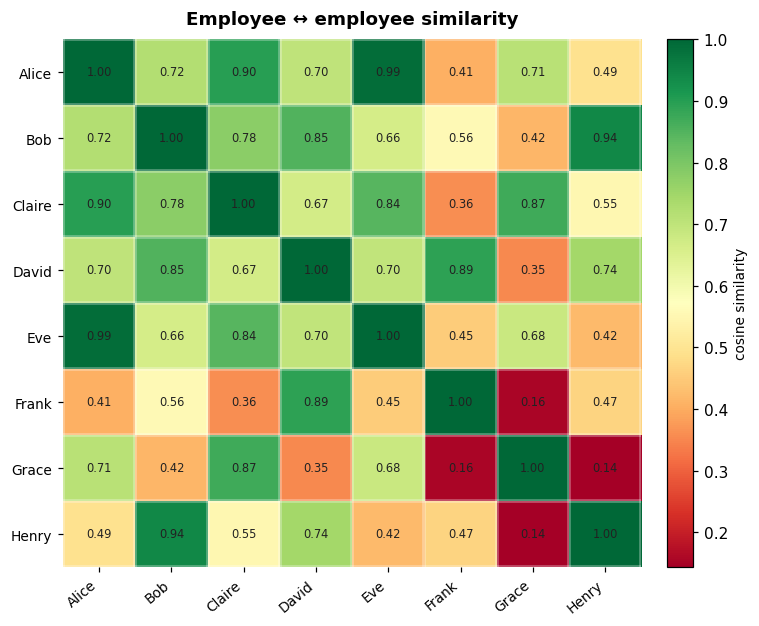

In [34]:
#@title 📊 Visualization (double-click to view the code) { display-mode: "form" }
sim = employee_similarity
fig, ax = plt.subplots(figsize=(7, 5.8))
im = ax.imshow(sim, cmap="RdYlGn", aspect="auto", vmin=float(sim.min()), vmax=1)
ax.set_xticks(range(n_employees)); ax.set_xticklabels(employee_names, rotation=40, ha="right", fontsize=9)
ax.set_yticks(range(n_employees)); ax.set_yticklabels(employee_names, fontsize=9)
for i in range(n_employees):
    for j in range(n_employees):
        ax.text(j, i, f"{sim[i, j]:.2f}", ha="center", va="center", fontsize=7.5, color="#222")
ax.set_xticks(np.arange(-0.5, n_employees, 1), minor=True)
ax.set_yticks(np.arange(-0.5, n_employees, 1), minor=True)
ax.grid(which="major", visible=False)
ax.grid(which="minor", color="white", lw=2.5)
ax.tick_params(which="minor", length=0)
for spine in ax.spines.values():
    spine.set_visible(False)
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04).set_label("cosine similarity", fontsize=9)
ax.set_title("Employee ↔ employee similarity", fontweight="bold", fontsize=12, pad=10)
plt.tight_layout(); plt.show()

**Homogeneous vs heterogeneous partners — example for Alice.** Sorting Alice's row of the
similarity matrix tells us who she'd team up with for a *similar* group (top, green) versus a
*complementary* group (bottom, red).

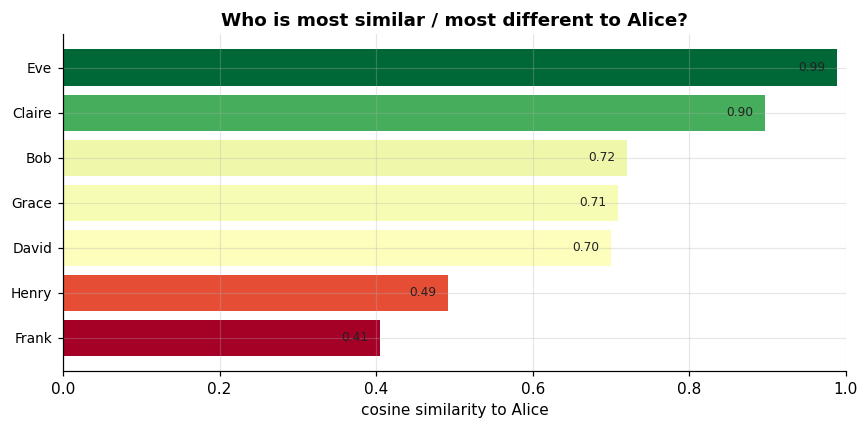

In [35]:
#@title 📊 Visualization (double-click to view the code) { display-mode: "form" }
target = "Alice"
ti = employee_names.index(target)
others = [j for j in range(n_employees) if j != ti]
vals = employee_similarity[ti, others]
order = np.argsort(vals)                      # ascending: least similar first
names = [employee_names[others[k]] for k in order]
vals = vals[order]

fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(range(len(vals)), vals, color=plt.get_cmap("RdYlGn")(plt.Normalize(vals.min(), vals.max())(vals)))
ax.set_yticks(range(len(vals))); ax.set_yticklabels(names, fontsize=9)
for k, v in enumerate(vals):
    ax.text(v - 0.015, k, f"{v:.2f}", va="center", ha="right", fontsize=8, color="#222")
ax.set_xlim(0, 1); ax.set_xlabel(f"cosine similarity to {target}")
ax.set_title(f"Who is most similar / most different to {target}?", fontweight="bold")
for s in ("top", "right"): ax.spines[s].set_visible(False)
ax.grid(axis="x", alpha=0.3)
plt.tight_layout(); plt.show()

display(HTML(f'''
<div style="display:flex;gap:14px;flex-wrap:wrap;font-family:system-ui,Segoe UI,Roboto,sans-serif;margin-top:4px">
  <div style="flex:1 1 230px;background:#eafaf0;border:1px solid #bfe9cf;border-radius:12px;padding:12px 14px">
    <div style="font-weight:800;color:#1f9d55">👥 Most alike — homogeneous</div>
    <div style="font-size:13px;color:#2c2350;margin-top:4px">{target} &amp; <b>{names[-1]}</b> · similarity {vals[-1]:.2f}<br>
      <span style="color:#777;font-size:12px">a deep-dive group with shared strengths</span></div>
  </div>
  <div style="flex:1 1 230px;background:#fdecea;border:1px solid #f2c4bd;border-radius:12px;padding:12px 14px">
    <div style="font-weight:800;color:#c0392b">🧩 Most complementary — heterogeneous</div>
    <div style="font-size:13px;color:#2c2350;margin-top:4px">{target} &amp; <b>{names[0]}</b> · similarity {vals[0]:.2f}<br>
      <span style="color:#777;font-size:12px">a mixed group that covers each other's gaps</span></div>
  </div>
</div>'''))

## 🏁 Final dashboard

Putting it together: the **final** recommendations (after business constraints), plus the
cohort suggestion for each employee — rendered as a small HTML dashboard.

In [36]:
#@title 📊 Visualization (double-click to view the code) { display-mode: "form" }
def final_dashboard():
    rows = ""
    for i, name in enumerate(employee_names):
        order = [j for j in np.argsort(final_scores[i])[::-1] if np.isfinite(final_scores[i, j])][:3]
        buddy = employee_names[find_most_similar_employee(i)]
        chips = ""
        for rank, j in enumerate(order):
            t = trainings[j]
            chips += f'''
              <div style="background:#f6f7fb;border:1px solid #e6e8ee;border-radius:10px;padding:8px 10px;margin:4px 0">
                <b>{['1.','2.','3.'][rank]} {t['title']}</b>
                <span style="float:right;color:#764ba2;font-weight:700">{final_scores[i, j]:.3f}</span><br>
                <span style="font-size:11px;color:#888">💰 ${t['cost']} · ⏱ {t['duration_hours']}h · 🎟 {t['available_seats']} seats
                {'· ⭐ mandatory' if t['mandatory_for_managers'] else ''}</span>
              </div>'''
        rows += f'''
          <div style="flex:1 1 270px;background:white;border-radius:16px;padding:16px;
               box-shadow:0 4px 14px rgba(0,0,0,.06)">
            <div style="font-size:16px;font-weight:800">{name}
              <span style="font-weight:400;color:#999;font-size:12px">· {employees[i]['role']}</span></div>
            <div style="font-size:12px;color:#667eea;margin:2px 0 8px">👥 cohort buddy: <b>{buddy}</b></div>
            {chips}
          </div>'''
    display(HTML(f'''
      <div style="font-family:system-ui,Segoe UI,Roboto,sans-serif;
           background:linear-gradient(135deg,#f5f7ff,#fdf5ff);padding:18px;border-radius:18px">
        <h2 style="margin:0 0 12px">📋 Internal Training Recommendations</h2>
        <div style="display:flex;flex-wrap:wrap;gap:14px">{rows}</div>
      </div>'''))

final_dashboard()

## ✅ What you built

You turned readable business data into practical recommendations using nothing but vector and
matrix operations:

**business objects → vectors → matrices → similarities → rankings → recommendations → constraints**

**NumPy skills practiced:** `np.array`, shape inspection, `axis` / `keepdims`, `np.linalg.norm`,
dot products, matrix multiplication (`@`), transpose, broadcasting, boolean masks, `np.argsort`,
`np.argmax`, and rich visualization (interactive HTML, heatmaps, distributions).

**The one idea to remember:**
```python
scores = employee_matrix_normalized @ training_matrix_normalized.T
```
A single matrix multiply scales one comparison up to *all* comparisons — the same trick powers
recommender systems, search, and many other AI systems.

### Try it yourself
- Add a new employee or training and re-run — the whole pipeline adapts.
- Tune the penalty weights in Step 7. How do the recommendations change?
- Use `employee_similarity` to cluster employees into cohorts (hint: this is where Block 2 / scikit-learn begins).